# Prospective Forecast — LightGBM (ILI / ARI)

Experimental notebook

## Setup

In [1]:
# install dependencies (uncomment if running in a fresh env / Colab)
# %pip install "lightgbm>=4.3" "lightgbmlss>=0.2.5" "matplotlib>=3.8"

In [2]:
import json
import sys
from pathlib import Path

import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

def find_repo_root(start: Path) -> Path:
    for p in [start, *start.parents]:
        if (p / "src" / "gridsearch_lgbm.py").exists():
            return p
    raise FileNotFoundError(
        "Could not locate repo root (src/gridsearch_lgbm.py not found above "
        f"{start}). Run this notebook from inside the MIGHTE-respicast-jointGBM checkout."
    )

ROOT_DIR = find_repo_root(Path.cwd())
print("Repo root:", ROOT_DIR)


Repo root: /home/nadillia/Documents/MIGHTE-respicast-jointGBM


In [3]:
sys.path.insert(0, str(ROOT_DIR / "src"))

%load_ext autoreload
%autoreload 2

from model_joint_twostage_eu import RuntimeConfig, run_prospective
import forecast_prospective as fp
from build_long_timeseries import resolve_long_timeseries

print("import OK")


import OK


/home/nadillia/Documents/MIGHTE-respicast-jointGBM/.venv/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [4]:
# Hub repo checkout (target-data + locations/forecasting-weeks files)
HUB_DIR = ROOT_DIR / "RespiCast-SyndromicIndicators"
LOCATIONS_FILE = HUB_DIR / "supporting-files" / "locations_iso2_codes.csv"
FORECASTING_WEEKS_FILE = HUB_DIR / "supporting-files" / "forecasting_weeks.csv"

if not LOCATIONS_FILE.exists():
    !git clone --depth 1 https://github.com/european-modelling-hubs/RespiCast-SyndromicIndicators.git "{HUB_DIR}"
else:
    !git -C "{HUB_DIR}" pull --ff-only


Already up to date.


In [5]:
DATA_FILE = ROOT_DIR / "data" / "processed" / "respicast_long_latest.csv"

canonical = resolve_long_timeseries(HUB_DIR)
DATA_FILE.parent.mkdir(parents=True, exist_ok=True)
canonical.to_csv(DATA_FILE, index=False)
print(f"Refreshed {DATA_FILE}: {len(canonical)} rows, "
      f"max truth_date={pd.to_datetime(canonical['truth_date']).max().date()}")


Refreshed /home/nadillia/Documents/MIGHTE-respicast-jointGBM/data/processed/respicast_long_latest.csv: 22357 rows, max truth_date=2026-08-09


## Config

In [6]:
TARGETS = ["ILI", "ARI"]

MODEL_ID = "ISI-LightGBM"

SUBMISSION_DIR = ROOT_DIR / "forecasts" / "prospective" / "submission"
RAW_DIR = ROOT_DIR / "forecasts" / "prospective" / "raw"
SAVE_RAW = False  # also write one raw CSV per target, in addition to the combined submission

NUM_BAGS = 25

RECENT_WEEKS_REQUIRED = 4
EXCLUDE_COVID = True
INCLUDE_GT_LEAD = True  # GT "nowcast" lag-1 feature (GT ~1 week ahead of the anchor); set False to disable
GT_MIN_CORR = 0.3  # drop a GT term/location pair whose same-week |correlation| with the target is below this

GOOGLE_TRENDS_FILE = ROOT_DIR / "google_preprocessing" / "data" / "processed" / "google_trends_preprocessed.csv"

LOCATIONS_SUBSET = None  
# the rest are defaults from forecast_prospective.py

## Load tuned hyperparameters

In [7]:
def load_best_params(target: str) -> dict:
    candidates = [
        ROOT_DIR / f"best_params_ablation_{target.lower()}.json",
        ROOT_DIR / ("best_params_ablation(ari).json" if target == "ARI" else "best_params_ablation.json"),
    ]
    for path in candidates:
        if path.exists():
            with open(path) as f:
                data = json.load(f)
            params = data.get("gt_proc", data)
            print(f"[{target}] loaded params from {path.name}")
            return params
    raise FileNotFoundError(f"No best-params JSON found for {target}. Checked: {[p.name for p in candidates]}")

BEST_PARAMS = {t: load_best_params(t) for t in TARGETS}
BEST_PARAMS


[ILI] loaded params from best_params_ablation_ili.json
[ARI] loaded params from best_params_ablation_ari.json


{'ILI': {'num_leaves': 79,
  'learning_rate': 0.0014017429596073063,
  'min_child_samples': 98,
  'feature_fraction': 0.9111152147885835,
  'rounds': 1000,
  'stage1_rounds_for_s2': 1000,
  'stage2_rounds': 229,
  'lambda_l2': 0.13230930634474714,
  's2_min_child_samples': 20},
 'ARI': {'num_leaves': 60,
  'learning_rate': 0.02042865987965193,
  'min_child_samples': 13,
  'feature_fraction': 0.6520594060694896,
  'rounds': 769,
  'stage1_rounds_for_s2': 769,
  'stage2_rounds': 167,
  'lambda_l2': 4.961044557836473,
  's2_min_child_samples': 103}}

## Run prospective forecast

In [8]:
def make_runtime_config(
    target_col,
    params,
    *,
    output,
    max_horizons=4,
    bag_frac=0.7,
    location_bag_frac=1.0,
    location_bag_min=1,
    own_lags=(1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 26, 52),
    donor_lags=(1, 2, 3, 4, 8, 12),
    donor_top_k=4,
    other_top_k=2,
    min_overlap=30,
    min_train_rows=800,
    target_mode="delta_log",
    sigma_mode="bounded",
    **overrides,
) -> RuntimeConfig:
    """RuntimeConfig with the rarely-changed structural params defaulted — pass any
    of them (or a RuntimeConfig field not listed here, e.g. num_bags) as a keyword
    to override for one call."""
    fields = dict(
        data_file=DATA_FILE,
        target=target_col,
        output=output,
        locations_file=LOCATIONS_FILE,
        forecasting_weeks_file=FORECASTING_WEEKS_FILE,
        max_horizons=max_horizons,
        num_bags=NUM_BAGS,
        bag_frac=bag_frac,
        location_bag_frac=location_bag_frac,
        location_bag_min=location_bag_min,
        seed=2026,
        stage1_rounds=params["rounds"],
        stage2_rounds=params["stage2_rounds"],
        own_lags=list(own_lags),
        donor_lags=list(donor_lags),
        donor_top_k=donor_top_k,
        other_top_k=other_top_k,
        min_overlap=min_overlap,
        min_train_rows=min_train_rows,
        target_mode=target_mode,
        sigma_mode=sigma_mode,
        locations_subset=LOCATIONS_SUBSET,
        recent_weeks_required=RECENT_WEEKS_REQUIRED,
        google_trends_file=GOOGLE_TRENDS_FILE,
        num_leaves=params["num_leaves"],
        learning_rate=params["learning_rate"],
        min_child_samples=params["min_child_samples"],
        feature_fraction=params["feature_fraction"],
        lambda_l2=params["lambda_l2"],
        s2_min_child_samples=params["s2_min_child_samples"],
        exclude_covid=EXCLUDE_COVID,
        include_gt_lead=INCLUDE_GT_LEAD,
        gt_min_corr=GT_MIN_CORR,
    )
    fields.update(overrides)
    return RuntimeConfig(**fields)


In [9]:
pred_by_target = {}
origin_by_target = {}

for t in TARGETS:
    target_col = fp.parse_targets(t)[0]
    params = BEST_PARAMS[t]

    cfg = make_runtime_config(
        target_col,
        params,
        output=SUBMISSION_DIR / f"tmp_{fp.target_slug(target_col)}.csv",
    )

    pred = run_prospective(cfg)
    if pred.empty:
        raise ValueError(f"No prospective forecasts generated for {target_col}")

    origin_date = str(pred["origin_date"].iloc[0])
    pred_by_target[t] = pred
    origin_by_target[t] = origin_date
    print(f"[{t}] origin_date={origin_date}  rows={len(pred)}")

    if SAVE_RAW:
        RAW_DIR.mkdir(parents=True, exist_ok=True)
        raw_path = RAW_DIR / f"{origin_date}-{MODEL_ID}-{fp.target_slug(target_col)}-raw.csv"
        pred.to_csv(raw_path, index=False)
        print(f"[{t}] saved raw: {raw_path}")


[ILI incidence] recent-truth filter: require >= 2026-07-12 (4 weeks), eligible=20, excluded=15
[ILI incidence] excluded_locations=['AT', 'BG', 'CY', 'CZ', 'DE', 'FR', 'GB-SCT', 'IT', 'LI', 'LV', 'NL', 'PL', 'PT', 'SE', 'SK']
[ILI incidence] Loaded Google Trends: 19840 rows, 17 terms
[GT] correlation filter (|r| >= 0.3): 17 kept, 0 dropped
[ILI incidence] anchor=2026-08-09 train_rows=27193 test_rows=80
[ILI incidence] season_bag_size=7/10 location_bag_size=20/20


/home/nadillia/Documents/MIGHTE-respicast-jointGBM/.venv/lib/python3.12/site-packages/lightgbmlss/utils.py:19: UserWarning: Converting a tensor with requires_grad=True to a scalar may lead to unexpected behavior.
Consider using tensor.detach() first. (Triggered internally at /pytorch/torch/csrc/autograd/generated/python_variable_methods.cpp:836.)
  nan=float(torch.nanmean(predt)),


*** Using GaussianFrozenLocBounded (frozen mu, sigma in [0.1, 0.6]) ***
[ILI incidence] successful_bags=25
[ILI incidence] per-location bag coverage: min=25 median=25.0 max=25
[ILI] origin_date=2026-08-19  rows=1840
[ARI incidence] recent-truth filter: require >= 2026-07-12 (4 weeks), eligible=18, excluded=17
[ARI incidence] excluded_locations=['AT', 'CH', 'CZ', 'DK', 'FR', 'GB-SCT', 'GR', 'HR', 'IT', 'LI', 'LV', 'MT', 'NO', 'PL', 'PT', 'SE', 'SK']
[ARI incidence] Loaded Google Trends: 19840 rows, 17 terms
[GT] correlation filter (|r| >= 0.3): 17 kept, 0 dropped
[ARI incidence] anchor=2026-08-09 train_rows=20979 test_rows=72
[ARI incidence] season_bag_size=7/10 location_bag_size=18/18
[ARI incidence] successful_bags=25
[ARI incidence] per-location bag coverage: min=25 median=25.0 max=25
[ARI] origin_date=2026-08-19  rows=1656


## Combine + save submission

In [10]:
origin_dates = sorted(set(origin_by_target.values()))
if len(origin_dates) != 1:
    raise RuntimeError(
        f"Targets produced inconsistent reference dates: {origin_by_target}. "
        "Aborting to avoid mixed-date submission."
    )
origin_date = origin_dates[0]

combined = pd.concat([pred_by_target[t] for t in TARGETS], ignore_index=True)
combined = combined.sort_values(["target", "location", "horizon", "output_type_id"]).reset_index(drop=True)

SUBMISSION_DIR.mkdir(parents=True, exist_ok=True)
sub_path = SUBMISSION_DIR / f"{origin_date}-{MODEL_ID}.csv"
combined.to_csv(sub_path, index=False)
print(f"Saved combined submission: {sub_path} ({len(combined)} rows)")

removed = 0
for patt in [f"{origin_date}-{MODEL_ID}-*.csv", f"{origin_date}-{MODEL_ID}_*.csv"]:
    for p in SUBMISSION_DIR.glob(patt):
        if p.name == sub_path.name:
            continue
        p.unlink(missing_ok=True)
        removed += 1
if removed:
    print(f"Removed {removed} legacy same-date submission file(s)")

combined.head()


Saved combined submission: /home/nadillia/Documents/MIGHTE-respicast-jointGBM/forecasts/prospective/submission/2026-08-19-ISI-LightGBM.csv (3496 rows)


,origin_date,target,target_end_date,horizon,location,output_type,output_type_id,value
0,2026-08-19,ARI incidence,2026-08-16,1,BE,quantile,0.010,153.078914
1,2026-08-19,ARI incidence,2026-08-16,1,BE,quantile,0.025,158.829294
2,2026-08-19,ARI incidence,2026-08-16,1,BE,quantile,0.050,163.946304
3,2026-08-19,ARI incidence,2026-08-16,1,BE,quantile,0.100,170.049538
4,2026-08-19,ARI incidence,2026-08-16,1,BE,quantile,0.150,174.294439


## PLot

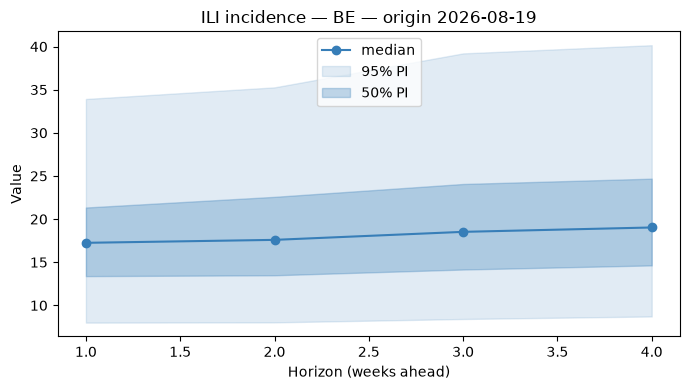

In [11]:
CHECK_TARGET = "ILI incidence"
CHECK_LOCATION = "BE"

sub = combined[(combined["target"] == CHECK_TARGET) & (combined["location"] == CHECK_LOCATION)]
piv = sub.pivot(index="horizon", columns="output_type_id", values="value").sort_index()

plt.figure(figsize=(7, 4))
plt.plot(piv.index, piv[0.5], marker="o", color="#377EB8", label="median")
plt.fill_between(piv.index, piv[0.025], piv[0.975], color="#377EB8", alpha=0.15, label="95% PI")
plt.fill_between(piv.index, piv[0.25], piv[0.75], color="#377EB8", alpha=0.3, label="50% PI")
plt.xlabel("Horizon (weeks ahead)")
plt.ylabel("Value")
plt.title(f"{CHECK_TARGET} — {CHECK_LOCATION} — origin {origin_date}")
plt.legend()
plt.tight_layout()
plt.show()


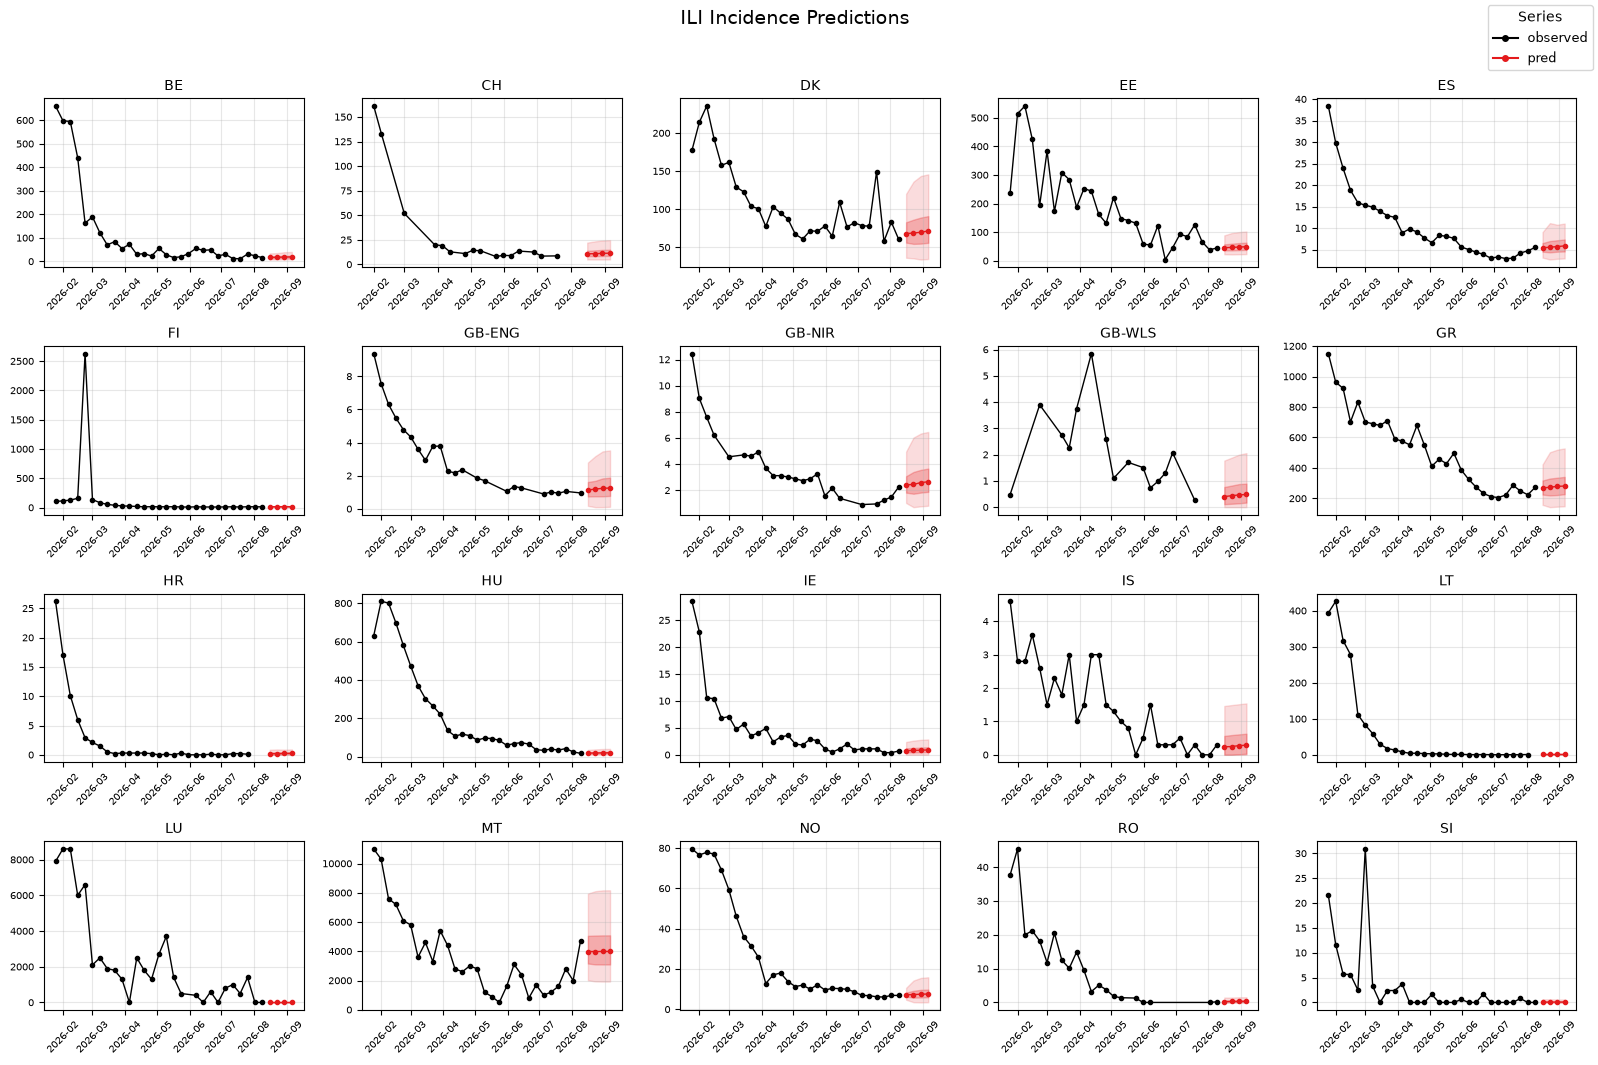

In [15]:
def plot_forecast_grid(combined, target_col, data_file, origin_date, weeks_history=30, ncols=5):
    truth = pd.read_csv(data_file)
    truth = truth[truth["target"] == target_col].copy()
    truth["truth_date"] = pd.to_datetime(truth["truth_date"])

    sub = combined[combined["target"] == target_col].copy()
    sub["target_end_date"] = pd.to_datetime(sub["target_end_date"])

    locations = sorted(sub["location"].unique())
    nrows = int(np.ceil(len(locations) / ncols))

    fig, axes = plt.subplots(nrows, ncols, figsize=(3.2 * ncols, 2.6 * nrows), sharex=False)
    axes = np.atleast_2d(axes)

    history_start = pd.to_datetime(origin_date) - pd.Timedelta(weeks=weeks_history)

    for i, loc in enumerate(locations):
        ax = axes[i // ncols, i % ncols]

        hist = truth[(truth["location"] == loc) & (truth["truth_date"] >= history_start)].sort_values("truth_date")
        ax.plot(hist["truth_date"], hist["value"], "-o", color="black", markersize=3, linewidth=1, label="observed")

        fc = sub[sub["location"] == loc]
        piv = fc.pivot(index="target_end_date", columns="output_type_id", values="value").sort_index()
        if not piv.empty:
            ax.plot(piv.index, piv[0.5], "-o", color="#E41A1C", markersize=3, linewidth=1, label="pred")
            if 0.025 in piv.columns and 0.975 in piv.columns:
                ax.fill_between(piv.index, piv[0.025], piv[0.975], color="#E41A1C", alpha=0.15)
            if 0.25 in piv.columns and 0.75 in piv.columns:
                ax.fill_between(piv.index, piv[0.25], piv[0.75], color="#E41A1C", alpha=0.25)

        ax.set_title(loc, fontsize=10)
        ax.tick_params(axis="x", rotation=45, labelsize=7)
        ax.tick_params(axis="y", labelsize=7)
        ax.grid(alpha=0.3)

    for j in range(len(locations), nrows * ncols):
        axes[j // ncols, j % ncols].axis("off")

    handles = [
        plt.Line2D([], [], color="black", marker="o", markersize=4, label="observed"),
        plt.Line2D([], [], color="#E41A1C", marker="o", markersize=4, label="pred"),
    ]
    fig.legend(handles=handles, loc="upper right", fontsize=9, title="Series")

    target_label = target_col.replace(" incidence", "").upper()
    fig.suptitle(f"{target_label} Incidence Predictions", fontsize=14, y=1.02)
    fig.tight_layout()
    return fig


fig = plot_forecast_grid(combined, CHECK_TARGET, DATA_FILE, origin_date)
plt.show()


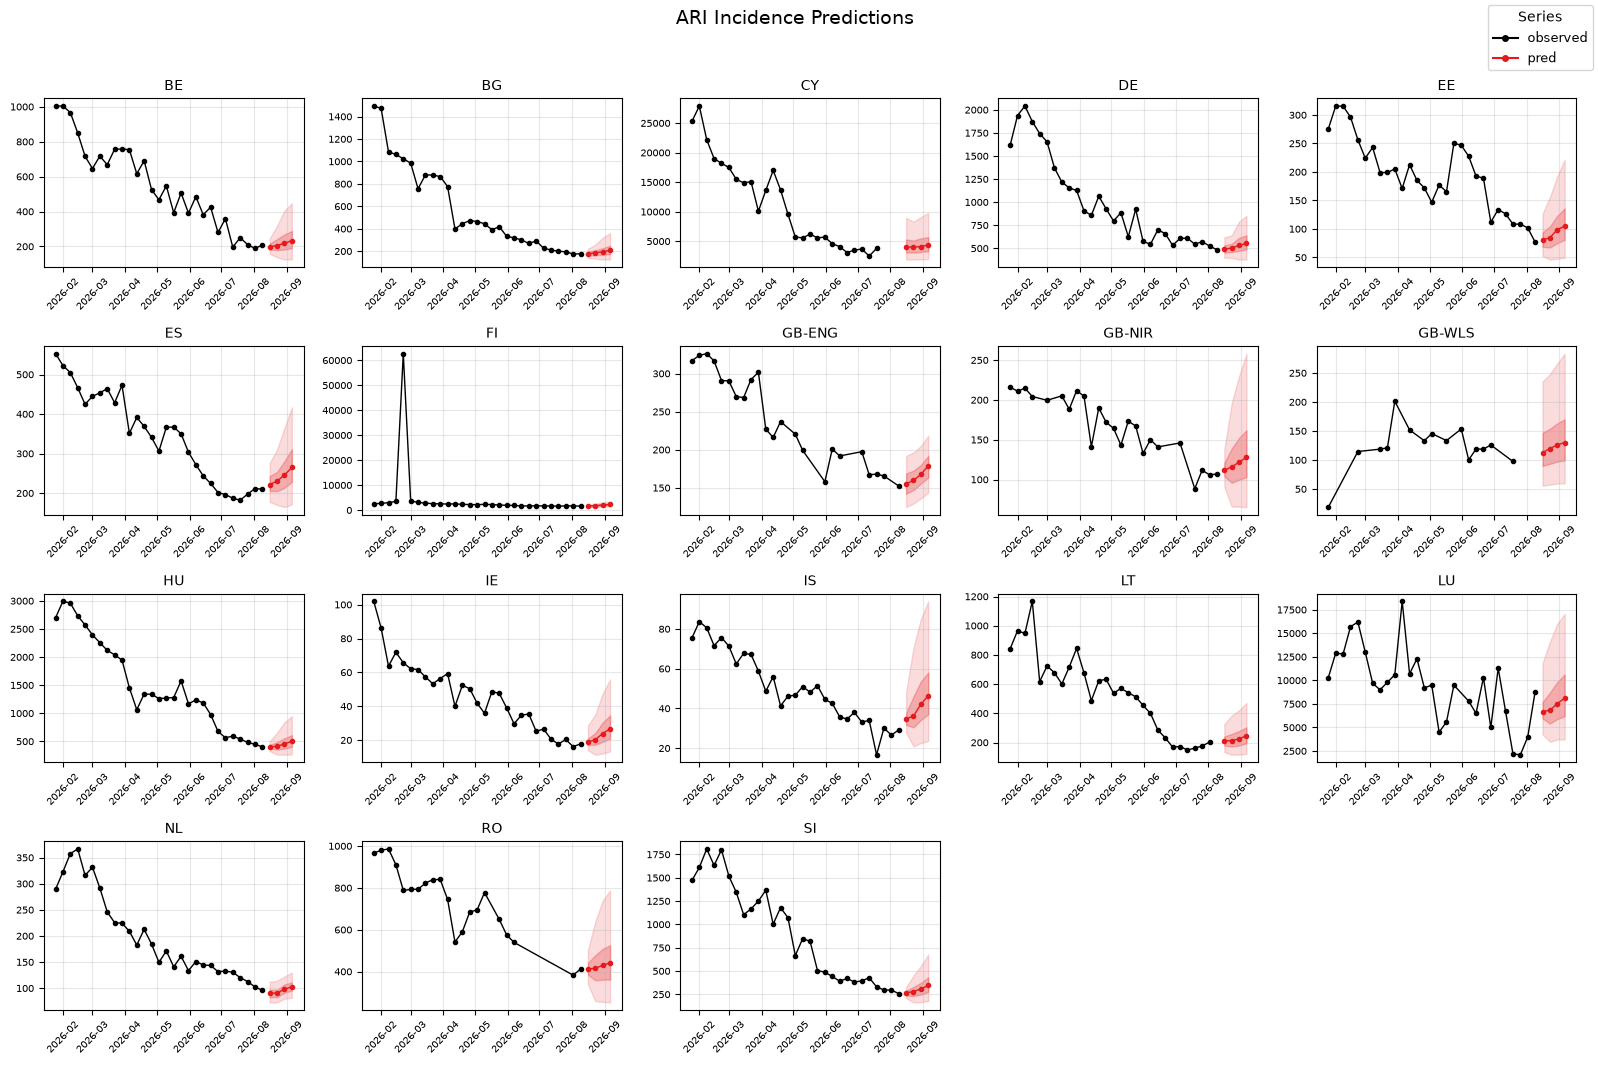

In [17]:
fig = plot_forecast_grid(combined, 'ARI incidence', DATA_FILE, origin_date)
plt.show()

## Check features

In [22]:
from model_joint_twostage_eu import _load_target_panel, build_features

CHECK_LOCATION = "HU"
GT_COL_TO_CHECK = None 

target_col_check = fp.parse_targets("ILI")[0]
other_col_check = fp.parse_targets("ARI")[0]


target_df_all = _load_target_panel(DATA_FILE, target_col_check, [CHECK_LOCATION])
anchor = pd.to_datetime(target_df_all[target_df_all["y"].notna()]["date"].max())
print(f"Anchor for {CHECK_LOCATION} ({target_col_check}): {anchor.date()}")

target_df = _load_target_panel(DATA_FILE, target_col_check, [CHECK_LOCATION], cutoff_date=anchor, calendar_end_date=anchor)
other_df = _load_target_panel(DATA_FILE, other_col_check, [CHECK_LOCATION], cutoff_date=anchor, calendar_end_date=anchor)

gt_df = pd.read_csv(GOOGLE_TRENDS_FILE, parse_dates=["date"])
gt_cols = [c for c in gt_df.columns if c not in ("location", "date")]
if GT_COL_TO_CHECK is None:
    GT_COL_TO_CHECK = gt_cols[0]
print(f"GT column: {GT_COL_TO_CHECK!r} (of {len(gt_cols)} available: {gt_cols})")

feat = build_features(
    target_df, other_df,
    own_lags=[1, 2], donor_lags=[1],
    same_target_donors={}, other_target_donors={},
    donor_top_k=0, other_top_k=0,
    gt_df=gt_df, include_gt_lead=INCLUDE_GT_LEAD, gt_min_corr=GT_MIN_CORR,
)

lag_cols = [f"{GT_COL_TO_CHECK}_lag{k}" for k in (0, 1, 2)]
if INCLUDE_GT_LEAD:
    lag_cols.append(f"{GT_COL_TO_CHECK}_lag-1")
feat[["date", "y", "y_lag_1", "y_lag_2"] + lag_cols].tail(8)


Anchor for HU (ILI incidence): 2026-08-09
GT column: 'avian influenza' (of 17 available: ['avian influenza', 'cluster_all', 'cold medicine', 'common cold', 'cough', 'dyspnea', 'fever', 'headache', 'influenza', 'influenza vaccine', 'nasal congestion', 'nausea', 'paracetamol', 'runny nose', 'sore throat', 'throat lozenge', 'virus'])
[GT] correlation filter (|r| >= 0.3): 17 kept, 0 dropped


,date,y,y_lag_1,y_lag_2,avian influenza_lag0,avian influenza_lag1,avian influenza_lag2,avian influenza_lag-1
611,2026-06-21,64.8,72.6,67.9,NaN,NaN,NaN,NaN
612,2026-06-28,35.7,64.8,72.6,NaN,NaN,NaN,NaN
613,2026-07-05,32.5,35.7,64.8,NaN,NaN,NaN,NaN
614,2026-07-12,39.3,32.5,35.7,NaN,NaN,NaN,NaN
615,2026-07-19,33.5,39.3,32.5,NaN,NaN,NaN,NaN
616,2026-07-26,42.0,33.5,39.3,NaN,NaN,NaN,NaN
617,2026-08-02,24.4,42.0,33.5,NaN,NaN,NaN,NaN
618,2026-08-09,16.8,24.4,42.0,NaN,NaN,NaN,NaN


In [ ]:
# Check for GT lag (and lead)
gt_loc = gt_df[gt_df["location"] == CHECK_LOCATION].set_index("date")[GT_COL_TO_CHECK]
last_date = feat["date"].iloc[-1]
last_row = feat[feat["date"] == last_date].iloc[0]

merged_corr = gt_df[gt_df["location"] == CHECK_LOCATION][["date", GT_COL_TO_CHECK]].merge(
    target_df_all[["date", "y"]], on="date"
)
corr = merged_corr[GT_COL_TO_CHECK].corr(merged_corr["y"])
passes_filter = abs(corr) >= GT_MIN_CORR if pd.notna(corr) else False

print(f"Row date: {last_date.date()}")
print(f"{CHECK_LOCATION} / {GT_COL_TO_CHECK!r} corr with target = {corr:.3f} "
      f"({'passes' if passes_filter else 'FAILS -- gt_min_corr will NaN this pair out below'} "
      f"gt_min_corr={GT_MIN_CORR})\n")

# lag0/1/2 look BACKWARD from the row's own date; lag-1 (the nowcast lead) looks
# FORWARD one week -- GT_df is never anchor-truncated, so it can genuinely hold a
# real value there even though `feat` itself has no row for that future date.
checks = [(k, last_date - pd.Timedelta(weeks=k), f"lag{k}") for k in (0, 1, 2)]
if INCLUDE_GT_LEAD:
    checks.append((-1, last_date + pd.Timedelta(weeks=1), "lag-1"))

for _, src_date, col_suffix in checks:
    raw_val = gt_loc.get(src_date, float("nan"))
    feat_val = last_row[f"{GT_COL_TO_CHECK}_{col_suffix}"]
    same = (pd.isna(raw_val) == pd.isna(feat_val)) and (pd.isna(raw_val) or raw_val == feat_val)
    if same:
        match = "OK"
    elif not passes_filter:
        match = "MISMATCH (expected -- correlation filter excludes this pair)"
    else:
        match = "MISMATCH"
    print(f"{col_suffix}: source_date={src_date.date()}  raw_gt={raw_val!r}  feature_value={feat_val!r}  [{match}]")
